In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.output_parsers import PydanticOutputParser
import operator
import time


In [18]:
from dotenv import load_dotenv
load_dotenv()


True

In [19]:
# Temperature 0.7 for creative, non-repetitive generation & optimization
generator_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.7
)

optimizer_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.7
)

# Temperature 0 for strict, deterministic evaluation in JSON mode
evaluator_llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0,
    model_kwargs={"response_format": {"type": "json_object"}}
)


In [20]:
# STATE
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["Approved", "Reject"]
    feedback: str
    iteration: int # to know how many iterations performed to generate the best tweet
    max_iteration: int # to close the loop and prevent infinite loops

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]


In [21]:
# First Node -> Post Generator
def generate_tweet(state: TweetState):
    messages = [
        SystemMessage(content="""
You are an expert X (Twitter) post writer.

Your job is to create a natural, concise, and engaging X post from the user's topic or idea.
Write like a real person, not like an AI or a marketing tool.

Guidelines:
- Keep the post concise and suitable for X.
- Use a calm, natural, and conversational tone.
- Start with an interesting but genuine opening.
- Clearly communicate the main idea.
- Avoid unnecessary words, repetition, and promotional language.
- Avoid exaggerated claims or corporate buzzwords.

Return only the generated X post text.
"""),
        HumanMessage(content=f"""
Create a punchy X post based on this topic:

{state["topic"]}
""")
    ]

    output = generator_llm.invoke(messages).content.strip()

    return {
        "tweet": output,
        "tweet_history": [output]
    }


In [22]:
# Structured Output for Evaluator using PydanticOutputParser
class EvaluationSchema(BaseModel):
    evaluation: Literal["Approved", "Reject"] = Field(
        description="Return 'Approved' ONLY if the X post is exceptional, highly engaging, authentic, and publish-ready with no room for meaningful improvement. Return 'Reject' if the post can be improved in hook, conciseness, tone, originality, shareability, or insight."
    )
    feedback: str = Field(
        description="Provide clear, specific, and actionable feedback explaining why the post was approved or exactly what needs improvement for the optimizer if rejected."
    )

parser = PydanticOutputParser(pydantic_object=EvaluationSchema)


In [23]:
# Second Node -> Post Evaluator
def evaluate_tweet(state: TweetState):
    time.sleep(1)
    format_instructions = parser.get_format_instructions()

    messages = [
        SystemMessage(content=f"""
You are a strict, top-tier editor for X (Twitter) content.
Your job is to critically evaluate whether the generated X post is truly publish-ready ("Approved") or if another round of optimization is needed ("Reject").

CRITICAL EDITORIAL STANDARDS:
- Do NOT approve a post merely because it is grammatically correct or relevant.
- Return "Reject" whenever meaningful improvement is possible in hook, punchiness, structure, or shareability.
- Return "Approved" ONLY if the post is already top-tier, highly authentic, punchy, and engaging.

Do not rewrite the post. Only evaluate it.

{format_instructions}
"""),
        HumanMessage(content=f"""
Evaluate this X post as a strict editor (Iteration {state['iteration']} of {state['max_iteration']}):

Topic:
{state["topic"]}

Post:
{state["tweet"]}

Provide your evaluation ("Approved" or "Reject") and detailed feedback.
""")
    ]

    res = evaluator_llm.invoke(messages)
    output = parser.parse(res.content)

    return {
        "evaluation": output.evaluation,
        "feedback": output.feedback,
        "feedback_history": [output.feedback]
    }


In [24]:
# Third Node -> Post Optimizer (Anti-Repetition Enabled)
def optimize_tweet(state: TweetState):
    time.sleep(1)
    prev_drafts = "\n---\n".join(state.get("tweet_history", []))

    messages = [
        SystemMessage(content="""
You are an expert X (Twitter) content strategist and post optimizer.
Your job is to rewrite the X post into a significantly improved, fresh version based on the evaluator's feedback.

CRITICAL RULES TO AVOID REPETITION:
1. Address Evaluator Feedback: Directly fix the specific weaknesses highlighted by the evaluator.
2. DO NOT repeat the exact same opening hook or phrasing from previous drafts.
3. Try a fresh angle, hook, or formatting style (e.g. story, contrast, practical observation, or bullet points).
4. Keep it Punchy & Authentic: Write like a real practitioner. Avoid corporate jargon, robotic summaries, and generic hashtags.

Return ONLY the new optimized X post text.
"""),
        HumanMessage(content=f"""
Optimize this X post based on evaluator feedback (Iteration {state['iteration'] + 1} of {state['max_iteration']}):

Original Topic:
{state["topic"]}

Current Post:
{state["tweet"]}

Evaluator Feedback:
{state["feedback"]}

Previous Drafts (DO NOT REPEAT PHRASING OR HOOKS FROM THESE):
{prev_drafts}

Create a significantly improved, fresh, authentic, and memorable version of this post.
""")
    ]

    output = optimizer_llm.invoke(messages).content.strip()
    iteration = state["iteration"] + 1

    return {
        "tweet": output,
        "iteration": iteration,
        "tweet_history": [output]
    }


In [25]:
def route_evaluation(state: TweetState) -> Literal["Approved", "Reject"]:
    if state["evaluation"] == "Approved" or state["iteration"] >= state["max_iteration"]:
        return "Approved"
    else:
        return "Reject"


In [26]:
graph = StateGraph(TweetState)
graph.add_node("generate_tweet", generate_tweet)
graph.add_node("evaluate_tweet", evaluate_tweet)
graph.add_node("optimize_tweet", optimize_tweet)

graph.add_edge(START, "generate_tweet")
graph.add_edge("generate_tweet", "evaluate_tweet")
graph.add_conditional_edges("evaluate_tweet", route_evaluation, {"Approved": END, "Reject": "optimize_tweet"})
graph.add_edge("optimize_tweet", "evaluate_tweet")


In [27]:
workflow = graph.compile()


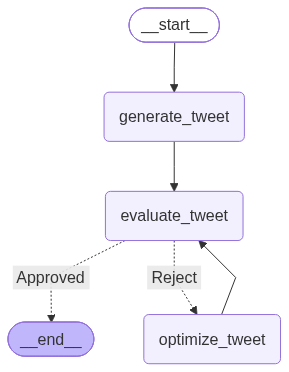

In [28]:
from IPython.display import Image, display

display(
    Image(workflow.get_graph().draw_mermaid_png())
)


In [29]:
topic = """
Why RAG systems can still give wrong answers even when the LLM itself is powerful, and how better document chunking, retrieval, and context selection can improve the results.
"""


In [30]:
result = workflow.invoke({"topic": topic, "iteration": 0, "max_iteration": 3})


In [31]:
# Display Best Final Approved Tweet
print("=== BEST FINAL TWEET ===\n")
print(result["tweet"])


=== BEST FINAL TWEET ===

"I've seen it happen to the best of us: a powerful LLM spits out wrong answers, leaving us scratching our heads. But what if I told you the culprit isn't the model itself, but the data it's fed? I'm talking about the often-overlooked world of document chunking, retrieval, and context selection.

Think of it like trying to find a needle in a haystack, but the haystack is on fire. Here are the top 3 ways to set your RAG system ablaze:

• **Chunking chaos**: When documents are chunked by topic, you're essentially throwing a bunch of unrelated stuff into the mix. It's like trying to find a recipe in a cookbook filled with random recipes.
• **Retrieval roulette**: Biased or incomplete retrieval processes are like playing a game of chance. You might get lucky, but more often than not, you'll end up with a bunch of irrelevant results.
• **Context collapse**: Without proper context selection, your model is forced to make assumptions, leading to errors and inconsistenc

In [32]:
# Display All Iteration Drafts and Feedback
print("=== ITERATION HISTORY ===")
tweets = result.get("tweet_history", [])
feedbacks = result.get("feedback_history", [])

for i in range(max(len(tweets), len(feedbacks))):
    print(f"\n--- DRAFT {i+1} ---")
    if i < len(tweets):
        print(f"Tweet:\n{tweets[i]}\n")
    if i < len(feedbacks):
        clean_fb = feedbacks[i].replace("🔍 EVALUATOR FEEDBACK:", "").strip()
        print(f"Feedback:\n{clean_fb}\n")


=== ITERATION HISTORY ===

--- DRAFT 1 ---
Tweet:
"Powerful LLMs aren't a magic fix. RAG (retrieve-and-generate) systems can still spit out wrong answers if the underlying data is flawed. Think of it like trying to find answers in a library with a terrible indexing system. Improving document chunking, retrieval, and context selection can make or break the results. Anyone else struggle with this?"

Feedback:
The post raises an interesting point about RAG systems, but it can be improved in terms of hook, conciseness, and originality. The analogy of a library with a terrible indexing system is a good start, but it feels a bit generic and could be replaced with something more unique. Additionally, the post could benefit from a clearer explanation of how better document chunking, retrieval, and context selection can improve results. The question at the end feels like a tacked-on attempt to engage the audience, but it's not particularly effective. Consider revising the post to make it more c